AIM : Objective
 The goal is to predict food delivery times based on customer location, restaurant location, weather, traffic, and other factors. This involves both data preprocessing and building predictive models using linear regression and logistic regression.


In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25


Exploratory Data Analysis (EDA)

In [3]:
df.shape

(200, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [5]:
df.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

So there are no missing values or null values above

In [6]:
(df == "").sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [7]:
df = df.drop_duplicates()

In [8]:

categorical_cols = df.select_dtypes(include = object).columns
categorical_cols

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location',
       'Weather_Conditions', 'Traffic_Conditions', 'Order_Priority',
       'Order_Time', 'Vehicle_Type'],
      dtype='object')

In [9]:

for cols in categorical_cols:
   print(f"\n{cols}:")
   print(df[cols].unique())
    


Order_ID:
['ORD0001' 'ORD0002' 'ORD0003' 'ORD0004' 'ORD0005' 'ORD0006' 'ORD0007'
 'ORD0008' 'ORD0009' 'ORD0010' 'ORD0011' 'ORD0012' 'ORD0013' 'ORD0014'
 'ORD0015' 'ORD0016' 'ORD0017' 'ORD0018' 'ORD0019' 'ORD0020' 'ORD0021'
 'ORD0022' 'ORD0023' 'ORD0024' 'ORD0025' 'ORD0026' 'ORD0027' 'ORD0028'
 'ORD0029' 'ORD0030' 'ORD0031' 'ORD0032' 'ORD0033' 'ORD0034' 'ORD0035'
 'ORD0036' 'ORD0037' 'ORD0038' 'ORD0039' 'ORD0040' 'ORD0041' 'ORD0042'
 'ORD0043' 'ORD0044' 'ORD0045' 'ORD0046' 'ORD0047' 'ORD0048' 'ORD0049'
 'ORD0050' 'ORD0051' 'ORD0052' 'ORD0053' 'ORD0054' 'ORD0055' 'ORD0056'
 'ORD0057' 'ORD0058' 'ORD0059' 'ORD0060' 'ORD0061' 'ORD0062' 'ORD0063'
 'ORD0064' 'ORD0065' 'ORD0066' 'ORD0067' 'ORD0068' 'ORD0069' 'ORD0070'
 'ORD0071' 'ORD0072' 'ORD0073' 'ORD0074' 'ORD0075' 'ORD0076' 'ORD0077'
 'ORD0078' 'ORD0079' 'ORD0080' 'ORD0081' 'ORD0082' 'ORD0083' 'ORD0084'
 'ORD0085' 'ORD0086' 'ORD0087' 'ORD0088' 'ORD0089' 'ORD0090' 'ORD0091'
 'ORD0092' 'ORD0093' 'ORD0094' 'ORD0095' 'ORD0096' 'ORD0097' 'ORD0

Label encoding 

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Traffic_Conditions"] = le.fit_transform(df["Traffic_Conditions"])
     

df["Traffic_Conditions"].head()

0    2
1    2
2    2
3    1
4    0
Name: Traffic_Conditions, dtype: int64

In [11]:
df.describe().columns

Index(['Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount'],
      dtype='object')

Outlier Detection :  Detecting outliers in numerical features using boxplots and others to handle them appropriately.


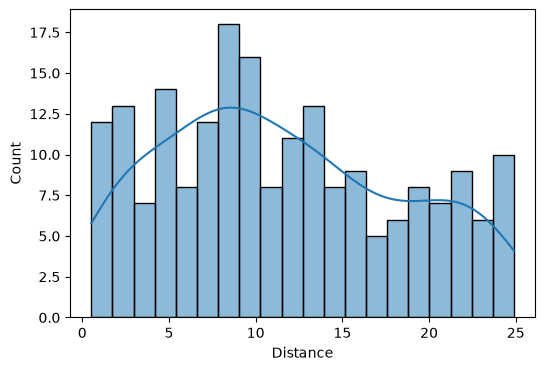

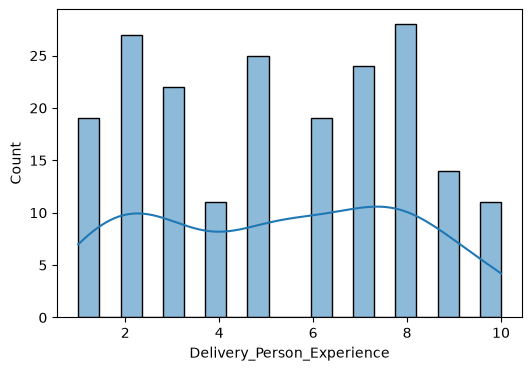

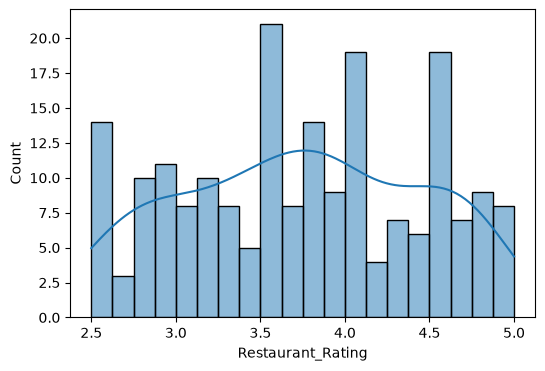

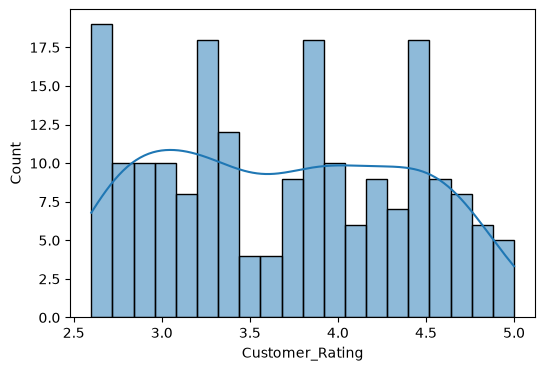

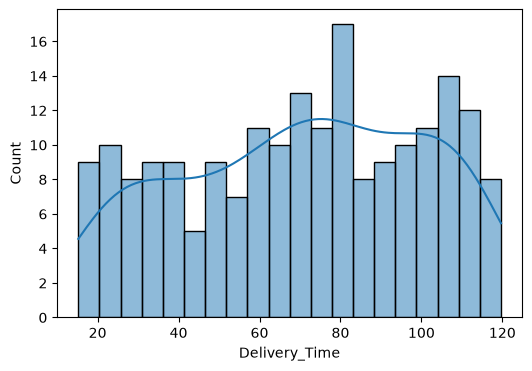

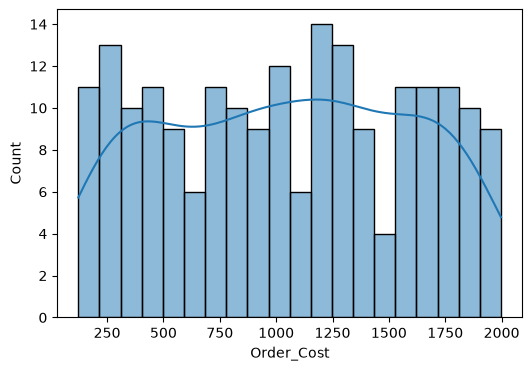

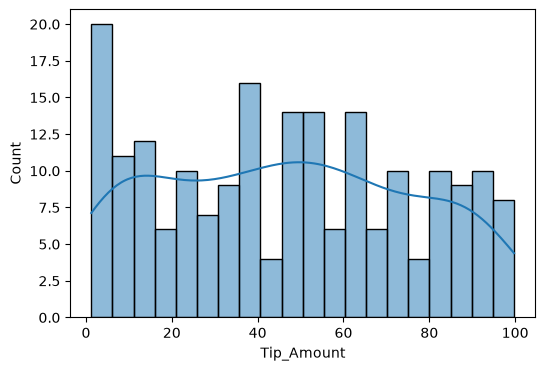

In [12]:
numeric_columns = ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating',
       'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[num_cols] ,kde = True,bins = 20  )

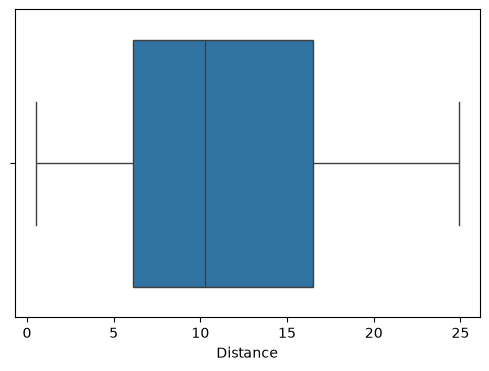

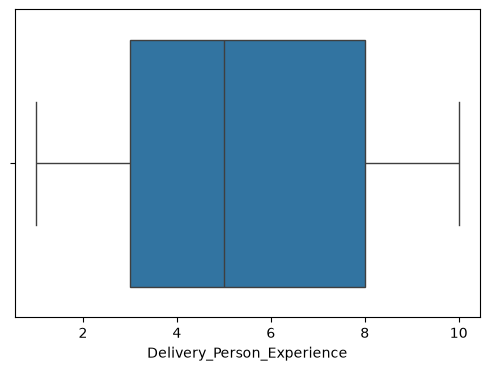

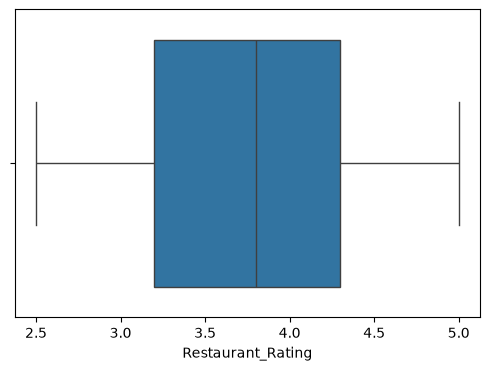

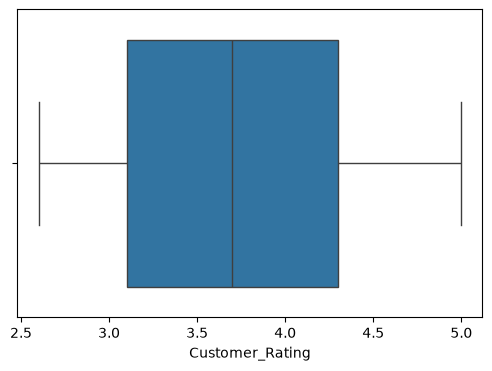

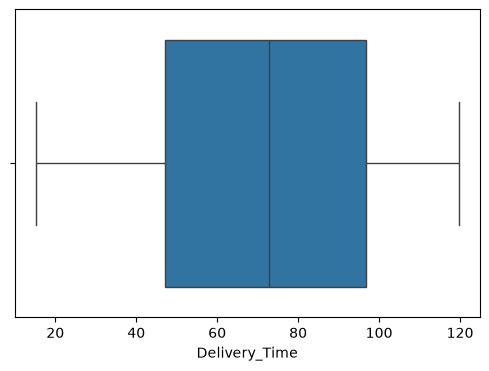

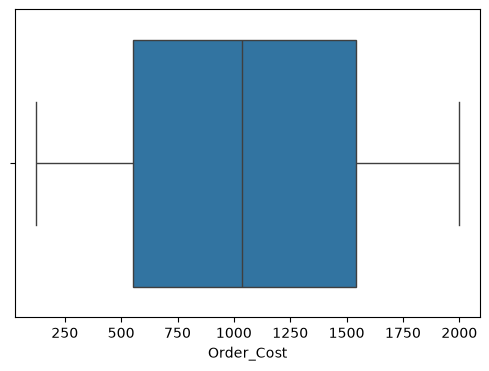

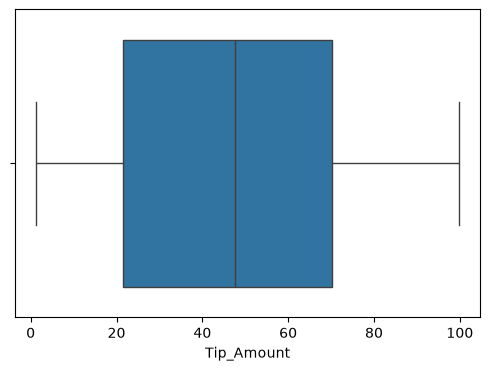

In [13]:
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[num_cols])

No-outliers here till now 

In [14]:
df_new = df.drop(columns=['Order_ID'])

In [15]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_Location           200 non-null    object 
 1   Restaurant_Location         200 non-null    object 
 2   Distance                    200 non-null    float64
 3   Weather_Conditions          200 non-null    object 
 4   Traffic_Conditions          200 non-null    int64  
 5   Delivery_Person_Experience  200 non-null    int64  
 6   Order_Priority              200 non-null    object 
 7   Order_Time                  200 non-null    object 
 8   Vehicle_Type                200 non-null    object 
 9   Restaurant_Rating           200 non-null    float64
 10  Customer_Rating             200 non-null    float64
 11  Delivery_Time               200 non-null    float64
 12  Order_Cost                  200 non-null    float64
 13  Tip_Amount                  200 non

Feature Engineering

Distance Calculation : 
Calculating the distance between the customer and restaurant using latitudes and longitudes (Haversine formula).


In [16]:

import pandas as pd
import math
import ast

# Takes each values of columns then, convert the string into the actual Python object
df_new["Customer_Location"] = df_new["Customer_Location"].apply(ast.literal_eval) 
df_new["Restaurant_Location"] = df_new["Restaurant_Location"].apply(ast.literal_eval)

def haversine(customer_loc, restaurant_loc):
    lat1, lon1 = customer_loc
    lat2, lon2 = restaurant_loc

    R = 6371 # it is average radius of Earth in km.

    # Here converting degrees to radians as python trigonometric functions need radians, not degrees.

    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2]) 

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Using the above formula in the images 

    a = (math.sin(dlat / 2) ** 2 +
         math.cos(lat1) * math.cos(lat2) *
         math.sin(dlon / 2) ** 2)

    c = 2 * math.asin(math.sqrt(a))

    return R * c

""" using the lambda function here which takes row as parameter and go to the haversine function , 
   just like selecting values from index in list we are selecting 
   "Customer_Location"and "Restaurant_Location" from row , The row , Pandas passes it automatically """    

df_new["locations_distance"] = df_new.apply( 

    lambda row: haversine(
        row["Customer_Location"],
        row["Restaurant_Location"]
    ),
    axis=1
)

df_new.head()

,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance
0,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,2,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,775.651198
1,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,2,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,1042.385597
2,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,2,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,476.220706
3,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,1,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,389.912629
4,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,0,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,806.505886


In [17]:
df_new = df_new.drop(columns=['Customer_Location','Restaurant_Location'])


In [18]:
df_new.head()

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance
0,1.57,Rainy,2,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,775.651198
1,21.32,Cloudy,2,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,1042.385597
2,6.95,Snowy,2,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,476.220706
3,13.79,Cloudy,1,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,389.912629
4,6.72,Rainy,0,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,806.505886


Time-Based Features:
 Here created new features related to the time of day, such as Rush Hour vs Non-Rush Hour, to improve predictions.


In [19]:
df_new["Rush_Hour"] = df_new["Order_Time"].map({
    "Morning": "Rush",
    "Afternoon": "Rush",
    "Evening": "Rush",
    "Night": "Non-Rush"
})

In [20]:
df_new.head().columns

Index(['Distance', 'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount', 'locations_distance', 'Rush_Hour'],
      dtype='object')

Correlation Analysis :
 Visualizing correlations between features and the target variable (Delivery_Time) to identify the most relevant predictors.


<Axes: >

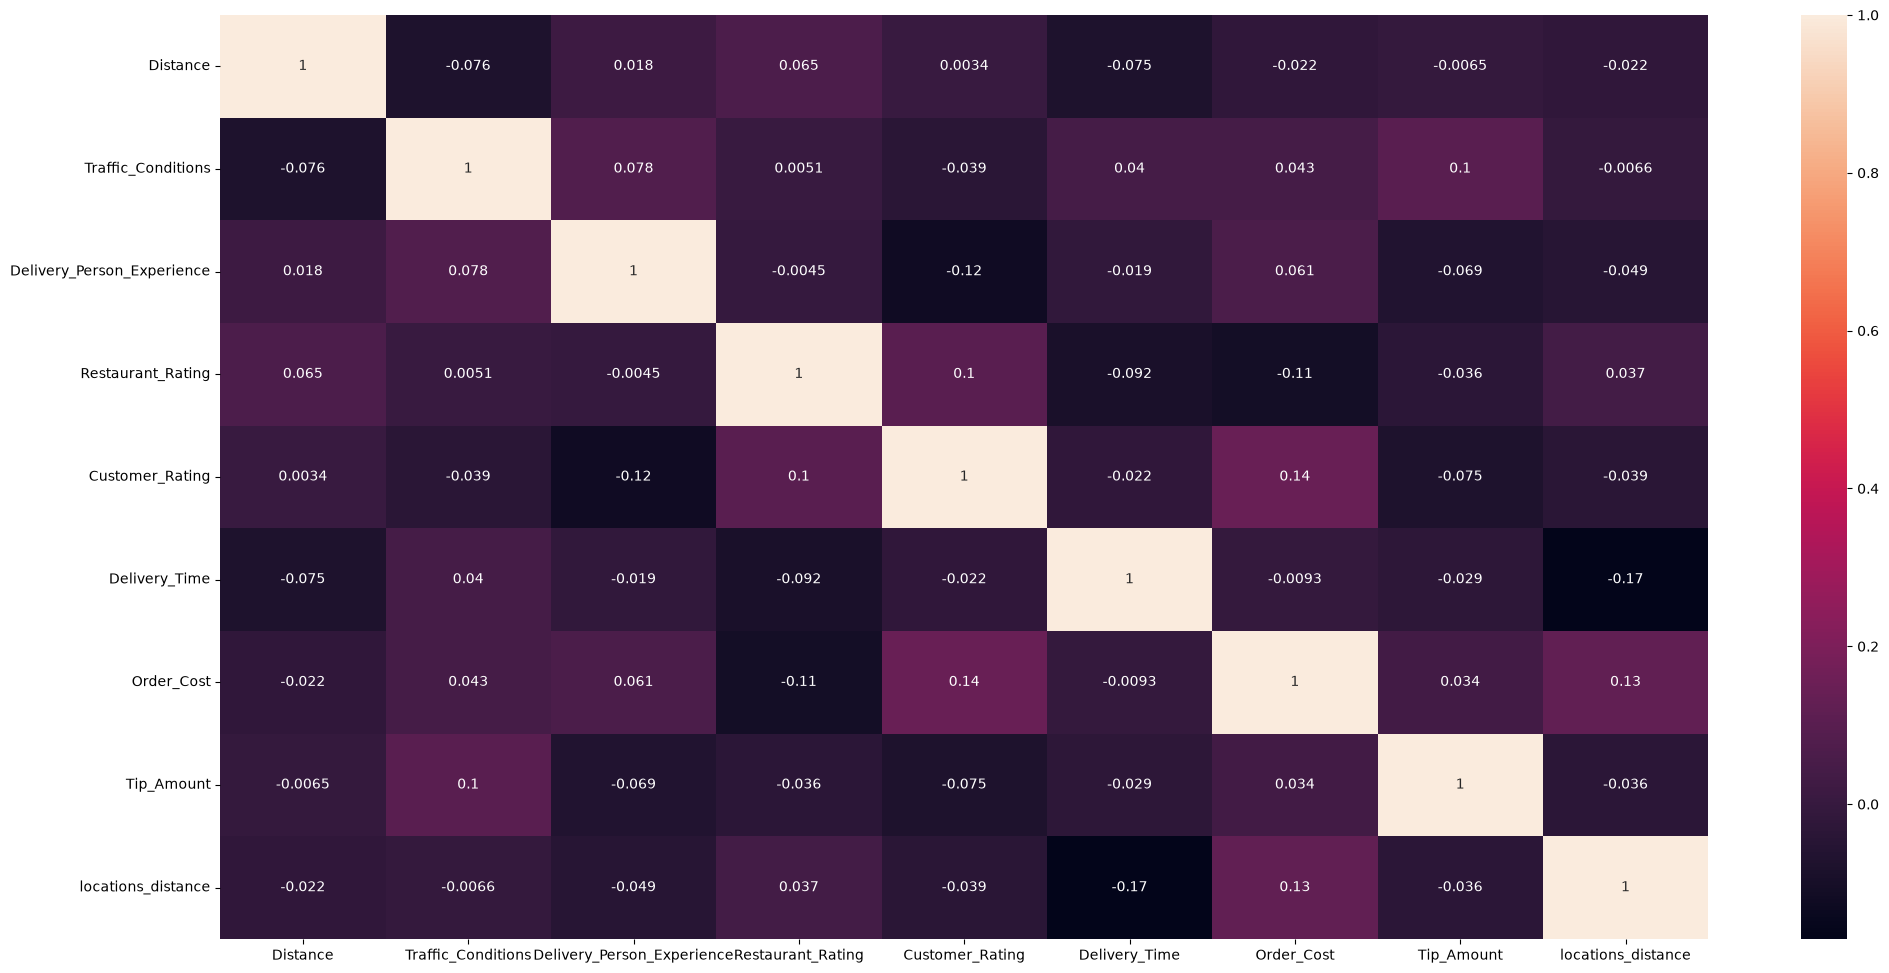

In [21]:
plt.figure(figsize=(24,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True)

In [22]:
categorical_cols = df_new.select_dtypes(include = object).columns
categorical_cols

Index(['Weather_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type',
       'Rush_Hour'],
      dtype='object')

Using one-hot encoding for categorical Variables

In [23]:
df_new = pd.get_dummies(df_new,columns=['Weather_Conditions', 'Order_Priority',
       'Order_Time', 'Vehicle_Type', 'Rush_Hour']  )
df_new

,Distance,Traffic_Conditions,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance,Weather_Conditions_Cloudy,...,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Rush_Hour_Non-Rush,Rush_Hour_Rush
0,1.57,2,4,4.1,3.0,26.22,1321.10,81.54,775.651198,False,...,True,True,False,False,False,False,False,True,False,True
1,21.32,2,8,4.5,4.2,62.61,152.21,29.02,1042.385597,True,...,False,False,False,False,True,False,False,True,True,False
2,6.95,2,9,3.3,3.4,48.43,1644.38,64.17,476.220706,False,...,False,False,False,False,True,False,True,False,True,False
3,13.79,1,2,3.2,3.7,111.63,541.25,79.23,389.912629,True,...,True,False,True,False,False,False,True,False,False,True
4,6.72,0,6,3.5,2.8,32.38,619.81,2.34,806.505886,False,...,False,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,23.82,0,8,4.7,4.0,50.39,1432.26,66.34,670.130652,True,...,True,False,False,False,True,False,True,False,True,False
196,6.09,2,8,3.0,3.6,90.54,1720.25,40.27,558.891202,False,...,False,False,False,False,True,True,False,False,True,False
197,20.61,0,4,2.9,3.4,73.20,1356.58,5.10,106.686689,False,...,True,True,False,False,False,False,True,False,False,True
198,24.06,0,9,3.9,4.8,53.94,354.39,85.25,880.580093,False,...,False,False,False,False,True,False,False,True,True,False


In [24]:
categorical_cols

Index(['Weather_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type',
       'Rush_Hour'],
      dtype='object')

Typecasting the bool to int type

In [25]:
bool_cols = df_new.select_dtypes(include='bool').columns
df_new[bool_cols] = df_new[bool_cols].astype(int)

In [26]:
df_new

,Distance,Traffic_Conditions,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance,Weather_Conditions_Cloudy,...,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Rush_Hour_Non-Rush,Rush_Hour_Rush
0,1.57,2,4,4.1,3.0,26.22,1321.10,81.54,775.651198,0,...,1,1,0,0,0,0,0,1,0,1
1,21.32,2,8,4.5,4.2,62.61,152.21,29.02,1042.385597,1,...,0,0,0,0,1,0,0,1,1,0
2,6.95,2,9,3.3,3.4,48.43,1644.38,64.17,476.220706,0,...,0,0,0,0,1,0,1,0,1,0
3,13.79,1,2,3.2,3.7,111.63,541.25,79.23,389.912629,1,...,1,0,1,0,0,0,1,0,0,1
4,6.72,0,6,3.5,2.8,32.38,619.81,2.34,806.505886,0,...,0,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,23.82,0,8,4.7,4.0,50.39,1432.26,66.34,670.130652,1,...,1,0,0,0,1,0,1,0,1,0
196,6.09,2,8,3.0,3.6,90.54,1720.25,40.27,558.891202,0,...,0,0,0,0,1,1,0,0,1,0
197,20.61,0,4,2.9,3.4,73.20,1356.58,5.10,106.686689,0,...,1,1,0,0,0,0,1,0,0,1
198,24.06,0,9,3.9,4.8,53.94,354.39,85.25,880.580093,0,...,0,0,0,0,1,0,0,1,1,0


Checking for outlier in the new 'locations_distance' column

<Axes: xlabel='locations_distance'>

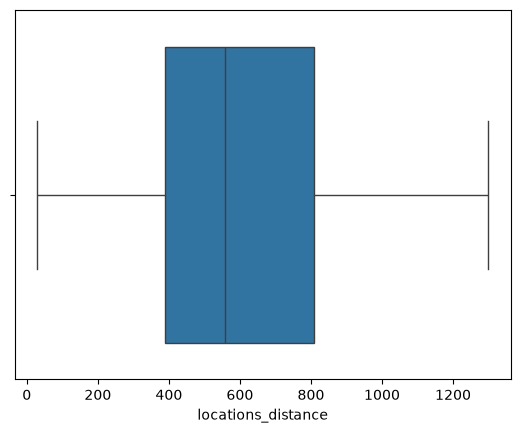

In [27]:
sns.boxplot(x = df_new['locations_distance'])

Standardize Numeric Columns: Standardize the continuous features 'Delivery_Time' for  consistency.


In [28]:

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# df[["Delivery_Time"]] = scaler.fit_transform(df[["Delivery_Time"]])

In [29]:
df_new.head().columns

Index(['Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount', 'locations_distance', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Order_Priority_High', 'Order_Priority_Low',
       'Order_Priority_Medium', 'Order_Time_Afternoon', 'Order_Time_Evening',
       'Order_Time_Morning', 'Order_Time_Night', 'Vehicle_Type_Bicycle',
       'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Rush_Hour_Non-Rush',
       'Rush_Hour_Rush'],
      dtype='object')

Linear Regression Model

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

In [31]:
X = df_new[[
    'Distance',
    'Traffic_Conditions',
    'Order_Priority_High', 
    'Order_Priority_Low',
    'Order_Priority_Medium',
    'locations_distance',
    ]]
# i don't know why using two distance gives more accuracy ?
y = df_new['Delivery_Time']

Using Train-Test Split :
 Spliting the dataset into training and testing sets ( 80/20 split).


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Standardize : Standardize the continuous features for  consistency using standard-scaler


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Building :
 Using Linear Regression to predict the Delivery Time based on features like Distance, Traffic_Conditions, and Order_Priority.

In [34]:
LinearModal = LinearRegression()

In [35]:
LinearModal.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-1.06, 0.87,-0.28, 0.42,-0.16,-3.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,70.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[15.86,15.28,13.26,12.66,11.79, 0. ]"


Using evaluation Metrics to evaluate the model using:
Mean Squared Error (MSE)
R-squared (R²)
Mean Absolute Error (MAE)


In [36]:
y_pred = LinearModal.predict(X_test_scaled)
r2_c = r2_score(y_test, y_pred)
mes = mean_squared_error(y_test, y_pred)
mar = mean_absolute_error(y_test, y_pred)
print(r2_c)
print(mes)
print(mar)

0.09035281918151206
841.3246812286236
24.46434099773172


high compare to other but still not good getting 

In [37]:
X_new = X.drop('Distance', axis=1)
y = df_new['Delivery_Time']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42)

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
LinearModal = LinearRegression()
LinearModal.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 1. ,-0.27, 0.4 ,-0.15,-3.45]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,70.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[15.85,15.25,12.7 ,12.45, 0. ]"


In [41]:

y_pred = LinearModal.predict(X_test_scaled)
r2_c = r2_score(y_test, y_pred)

mes = mean_squared_error(y_test, y_pred)
mar = mean_absolute_error(y_test, y_pred)
print(r2_c)
print(mes)
print(mar)


0.07599941233429552
854.6000210470942
24.66120180782228


I tried what i learn till now , i think the data are not good or if i am doing any thing wrong informed me please 

In [42]:
X_new2 = X.drop('locations_distance', axis=1)
y = df_new['Delivery_Time']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new2, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
LinearModal = LinearRegression()
LinearModal.fit(X_train_scaled, y_train)
y_pred = LinearModal.predict(X_test_scaled)
r2_c = r2_score(y_test, y_pred)
mes = mean_squared_error(y_test, y_pred)
mar = mean_absolute_error(y_test, y_pred)
print(r2_c)
print(mes)
print(mar)

0.01511534851449925
910.9111564688556
25.427368226878286


I have show you the three tests. Using both the location and the distance gives me more accuracy.I think using both increases redundent data due to which it increases .

In [44]:
df['Delivery_Time'].head(4)

0     26.22
1     62.61
2     48.43
3    111.63
Name: Delivery_Time, dtype: float64

In [45]:
df_new['Delivery_Time'].head(4)

0     26.22
1     62.61
2     48.43
3    111.63
Name: Delivery_Time, dtype: float64

Finding the mid-point in the 'Delivery_Time' fetures which give the 'Delivery_Status' such as "Fast"(1) or "Delayed"(0).

In [46]:
df_new['Delivery_Time'].median()

np.float64(72.775)

In [47]:
def check_status(x): # again take help here 
    if x > 72.775:
        return 1
    else:
        return 0

df_new["Delivery_Status"] = df_new["Delivery_Time"].apply(check_status)

In [48]:
df_new.columns

Index(['Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount', 'locations_distance', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Order_Priority_High', 'Order_Priority_Low',
       'Order_Priority_Medium', 'Order_Time_Afternoon', 'Order_Time_Evening',
       'Order_Time_Morning', 'Order_Time_Night', 'Vehicle_Type_Bicycle',
       'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Rush_Hour_Non-Rush',
       'Rush_Hour_Rush', 'Delivery_Status'],
      dtype='object')

In [49]:
X = df_new[[
   'Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
        'Order_Cost',
       'Tip_Amount', 'locations_distance', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Order_Priority_High', 'Order_Priority_Low',
       'Order_Priority_Medium', 'Order_Time_Afternoon', 'Order_Time_Evening',
       'Order_Time_Morning', 'Order_Time_Night', 'Vehicle_Type_Bicycle',
       'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Rush_Hour_Non-Rush',
       'Rush_Hour_Rush'
    
    ]]
y = df_new['Delivery_Status']

Model Implementation:
 Using Logistic Regression to predict the delivery status.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,  stratify=y, test_size=0.2, random_state=42) # since it is using the discrete not continious value so we are using stratify = y

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


LogisticModal = LogisticRegression()



LogisticModal.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [51]:
y_pred = LogisticModal.predict(X_test_scaled)

 Evaluation using metrics such as:


Accuracy
Precision
Recall
F1-score
Confusion Matrix


In [52]:

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

In [53]:

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("Confusion Matrix:\n", cm)

Accuracy: 0.55
Precision: 0.5454545454545454
Recall: 0.6
F1 Score: 0.5714285714285714
Confusion Matrix:
 [[10 10]
 [ 8 12]]


# **Phase 3: Reporting and Insights**

## Compare the Linear Regression and Logistic Regression models based on their performance

COMPARISION TABLE :

| Metric         | Linear Regression          | Logistic Regression           |
| -------------- | -------------------------- | ----------------------------- |
| **Goal**           | Predict exact time         | Predict delivery_status         |
| **Main Metric**   | R² Score                   | Accuracy                      |
| **Performance**   | 0.090 , 0.075 , 0.015          | 0.55              |
| **Relation** | Weak with feature  | Moderate with feature |


# Visualize the results using confusion matrices and ROC curves.

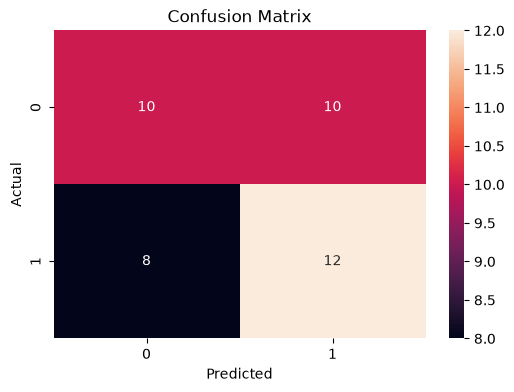

In [54]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="rocket")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = LogisticModal.predict_proba(X_test_scaled)[:, 1]




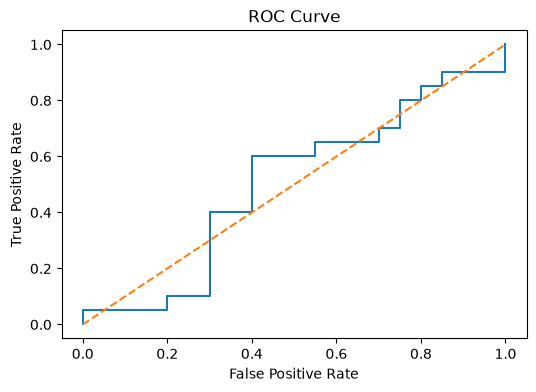

In [56]:

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
     

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()


# Conclusion 
The Linear Regression model achieved an R² score of approximately 0.09, which indicates that the selected features were able to explain only a small portion of the variation in delivery time. This suggests that delivery time is influenced by several other factors that were not included in the dataset. Similarly, the Logistic Regression model achieved an accuracy of around 55% in predicting delivery status. While this is better than random guessing, it also indicates that the model has room for improvement and cannot yet provide highly reliable predictions.